<a href="https://colab.research.google.com/github/iruy-fr/bubble-heap-sort/blob/main/analise_ordenacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!git clone https://github.com/iruy-fr/bubble-heap-sort.git
import os
os.listdir("bubble-heap-sort")


fatal: destination path 'bubble-heap-sort' already exists and is not an empty directory.


['README.md', '.gitignore', '.git']

In [23]:
import random
import time
import copy
import matplotlib.pyplot as plt

In [24]:
# ==============================
# BUBBLE SORT (O(n²))
# ==============================
# Compara elementos vizinhos e troca se estiverem fora de ordem

def bubble_sort(v):
    n = len(v)
    for i in range(n):
        trocou = False

        for j in range(0, n - i - 1):
            if v[j] > v[j + 1]:
                v[j], v[j + 1] = v[j + 1], v[j]
                trocou = True

        # Se não houve troca, já está ordenado (melhor caso O(n))
        if not trocou:
            break


# ==============================
# HEAP SORT (O(n log n))
# ==============================
# Usa estrutura de heap (árvore binária)

def heapify(v, n, i):
    maior = i
    esq = 2*i + 1
    dir = 2*i + 2

    if esq < n and v[esq] > v[maior]:
        maior = esq

    if dir < n and v[dir] > v[maior]:
        maior = dir

    if maior != i:
        v[i], v[maior] = v[maior], v[i]
        heapify(v, n, maior)


def heap_sort(v):
    n = len(v)

    # Construir o heap
    for i in range(n//2 - 1, -1, -1):
        heapify(v, n, i)

    # Extrair elementos do heap
    for i in range(n-1, 0, -1):
        v[i], v[0] = v[0], v[i]
        heapify(v, i, 0)

In [25]:
# ==============================
# FUNÇÕES AUXILIARES
# ==============================

# Gera vetor aleatório
def gerar_vetor(n):
    return [random.randint(0, 10000) for _ in range(n)]

# Mede tempo de execução
def testar(algoritmo, vetor):
    v = copy.copy(vetor)  # evita alterar o original
    inicio = time.time()
    algoritmo(v)
    fim = time.time()
    return (fim - inicio) * 1000  # tempo em ms

In [26]:
tamanhos = [1000, 3000, 5000]
execucoes = 5

bubble_resultados = []
heap_resultados = []

print("=== INÍCIO DOS TESTES ===\n")

for n in tamanhos:
    tempos_bubble = []
    tempos_heap = []

    print(f"Testando vetor de tamanho {n}...")

    for i in range(execucoes):
        vetor = gerar_vetor(n)

        tempo_b = testar(bubble_sort, vetor)
        tempo_h = testar(heap_sort, vetor)

        tempos_bubble.append(tempo_b)
        tempos_heap.append(tempo_h)

        print(f"  Execução {i+1}: Bubble = {tempo_b:.2f} ms | Heap = {tempo_h:.2f} ms")

    media_b = sum(tempos_bubble) / execucoes
    media_h = sum(tempos_heap) / execucoes

    bubble_resultados.append(media_b)
    heap_resultados.append(media_h)

    print(f"→ MÉDIA ({n}): Bubble = {media_b:.2f} ms | Heap = {media_h:.2f} ms\n")

print("=== RESULTADO FINAL ===")
for i in range(len(tamanhos)):
    print(f"Tamanho {tamanhos[i]} → Bubble: {bubble_resultados[i]:.2f} ms | Heap: {heap_resultados[i]:.2f} ms")

=== INÍCIO DOS TESTES ===

Testando vetor de tamanho 1000...
  Execução 1: Bubble = 51.20 ms | Heap = 2.37 ms
  Execução 2: Bubble = 50.00 ms | Heap = 2.38 ms
  Execução 3: Bubble = 49.61 ms | Heap = 2.33 ms
  Execução 4: Bubble = 54.58 ms | Heap = 2.36 ms
  Execução 5: Bubble = 50.78 ms | Heap = 2.32 ms
→ MÉDIA (1000): Bubble = 51.23 ms | Heap = 2.35 ms

Testando vetor de tamanho 3000...
  Execução 1: Bubble = 513.20 ms | Heap = 8.94 ms
  Execução 2: Bubble = 536.70 ms | Heap = 8.66 ms
  Execução 3: Bubble = 512.81 ms | Heap = 8.56 ms
  Execução 4: Bubble = 529.77 ms | Heap = 8.62 ms
  Execução 5: Bubble = 517.30 ms | Heap = 8.51 ms
→ MÉDIA (3000): Bubble = 521.96 ms | Heap = 8.66 ms

Testando vetor de tamanho 5000...
  Execução 1: Bubble = 1518.70 ms | Heap = 15.15 ms
  Execução 2: Bubble = 1378.76 ms | Heap = 17.32 ms
  Execução 3: Bubble = 1500.15 ms | Heap = 15.18 ms
  Execução 4: Bubble = 1387.87 ms | Heap = 17.47 ms
  Execução 5: Bubble = 2867.25 ms | Heap = 31.84 ms
→ MÉDIA (50

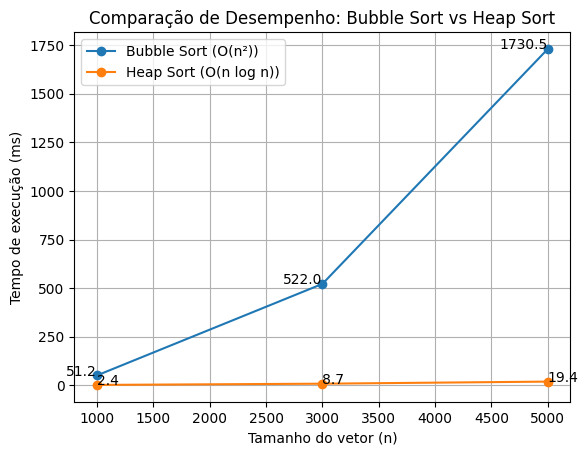

In [27]:
plt.figure()

plt.plot(tamanhos, bubble_resultados, marker='o', label='Bubble Sort (O(n²))')
plt.plot(tamanhos, heap_resultados, marker='o', label='Heap Sort (O(n log n))')

# Mostrar valores nos pontos
for i, txt in enumerate(bubble_resultados):
    plt.text(tamanhos[i], bubble_resultados[i], f"{round(txt,1)}", ha='right')

for i, txt in enumerate(heap_resultados):
    plt.text(tamanhos[i], heap_resultados[i], f"{round(txt,1)}", ha='left')

plt.xlabel("Tamanho do vetor (n)")
plt.ylabel("Tempo de execução (ms)")
plt.title("Comparação de Desempenho: Bubble Sort vs Heap Sort")

plt.legend()
plt.grid()

plt.show()